# Воспроизводимый preprocessing каталога фильмов

**Решение преподавателя. Продолжительность: 90 минут.**

Используется тот же `MoviesOnStreamingPlatforms.csv`. Исторической частью считаем фильмы до 2019 года включительно, новой выгрузкой — фильмы 2020–2021 годов. Преобразователь обучается только на исторической части и затем применяется к новым данным.

**Источник датасета:** [https://github.com/Swapnajacontribution/Datasets/blob/main/MoviesOnStreamingPlatforms.csv](https://github.com/Swapnajacontribution/Datasets/blob/main/MoviesOnStreamingPlatforms.csv)


Результаты:

- корректное разделение `fit` и `transform`;
- числовой и категориальный контуры;
- `ColumnTransformer` и `Pipeline` без модели;
- сохранение объекта preprocessing;
- матрицы исторических и новых признаков.

In [1]:
# -----------------------------------------------------------------------------
# Назначение ячейки: настроить библиотеки, версии и универсальные пути проекта.
# Путь к данным определяется автоматически для VS Code, Jupyter и Google Colab.
# Папки processed и outputs создаются при необходимости, поэтому сохранение файлов
# не зависит от того, были ли эти каталоги заранее созданы вручную.
# -----------------------------------------------------------------------------

from pathlib import Path
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определяем, выполняется ли notebook в Google Colab.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Python:", sys.version.split()[0])
print("Операционная система:", platform.system())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Google Colab:", IN_COLAB)
print("Текущая рабочая папка:", Path.cwd())


def find_project_root() -> Path:
    """Ищет папку пары по наличию исходного CSV.

    Функция позволяет запускать notebook:
    - из корня папки пары;
    - из подпапки notebooks в VS Code или Jupyter;
    - в Google Colab после распаковки папки пары в /content.
    """
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    marker = Path("data/raw/MoviesOnStreamingPlatforms.csv")
    for candidate in candidates:
        if (candidate / marker).exists():
            return candidate

    # Дополнительные типовые расположения для Google Colab.
    colab_candidates = [
        Path('/content'),
        Path('/content/01_types_and_reshape'),
        Path('/content/02_aggregation_and_datamart'),
        Path('/content/03_scaling_methods'),
        Path('/content/04_reproducible_preprocessing'),
    ]
    for candidate in colab_candidates:
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        "Не найден data/raw/MoviesOnStreamingPlatforms.csv. "
        "Распакуйте архив пары целиком и запустите notebook повторно."
    )


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR / "MoviesOnStreamingPlatforms.csv"
print("Корень проекта:", PROJECT_ROOT)
print("Исходный файл:", DATA_PATH)

Python: 3.10.5
Операционная система: Windows
pandas: 2.0.1
NumPy: 1.23.5
Google Colab: False
Текущая рабочая папка: d:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.2 Воспроизводимый preprocessing\notebooks
Корень проекта: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.2 Воспроизводимый preprocessing
Исходный файл: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.2 Воспроизводимый preprocessing\data\raw\MoviesOnStreamingPlatforms.csv


In [2]:
# -----------------------------------------------------------------------------
# Назначение ячейки: применить единые правила подготовки исходного каталога.
# Функция создает копию таблицы, приводит типы, нормализует текст и рассчитывает
# производные признаки. Единая функция особенно важна для preprocessing: исторические
# и новые данные должны проходить одну и ту же логику до fit/transform.
# -----------------------------------------------------------------------------

def prepare_movies(df: pd.DataFrame) -> pd.DataFrame:
    """Подготавливает каталог фильмов для анализа.

    Параметры
    ---------
    df : pd.DataFrame
        Исходная таблица без предварительного изменения.

    Возвращает
    ----------
    pd.DataFrame
        Новую таблицу с приведенными типами и производными признаками.
    """
    # Создаем независимую копию, чтобы функция не изменяла исходный DataFrame.
    result = df.copy()

    # Удаляем технический индекс, который был записан в исходный CSV.
    if "Unnamed: 0" in result.columns:
        result = result.drop(columns=["Unnamed: 0"])

    # Переименовываем поля, чтобы с ними было удобнее работать в Python.
    result = result.rename(columns={
        "ID": "movie_id",
        "Title": "title",
        "Year": "release_year",
        "Age": "age_rating",
        "Rotten Tomatoes": "rating_score",
        "Prime Video": "Prime_Video",
        "Disney+": "Disney_Plus",
        "Type": "type_code",
    })

    # Рейтинг вида "98/100" преобразуем в число 98.
    result["rating_score"] = pd.to_numeric(
        result["rating_score"].astype("string").str.replace("/100", "", regex=False),
        errors="coerce",
    )
    # errors="coerce" превращает некорректные значения в NaN, а nullable-тип Int64
    # позволяет хранить целые годы вместе с возможными пропусками.
    result["release_year"] = pd.to_numeric(result["release_year"], errors="coerce").astype("Int64")

    # Приводим возрастные категории к единому виду.
    result["age_rating"] = (
        result["age_rating"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({"all": "0+", "<na>": "unknown"})
        .fillna("unknown")
    )

    # Создаем признаки, которые понадобятся в следующих частях занятия.
    # Фиксированный опорный год делает расчет воспроизводимым: результат не меняется
    # автоматически при запуске notebook в другом календарном году.
    reference_year = 2026
    result["movie_age"] = reference_year - result["release_year"].astype("float64")
    result["decade"] = (result["release_year"].astype("float64") // 10 * 10).astype("Int64")
    result["title_length"] = result["title"].astype("string").str.len().astype("Int64")

    platform_columns = ["Netflix", "Hulu", "Prime_Video", "Disney_Plus"]
    # Так как платформенные столбцы содержат 0/1, сумма по строке равна числу
    # сервисов, на которых доступен конкретный фильм.
    result["platform_count"] = result[platform_columns].sum(axis=1).astype("int64")
    result["availability_group"] = np.where(
        result["platform_count"].gt(1), "multi_platform", "single_platform"
    )

    result["rating_band"] = pd.cut(
        result["rating_score"],
        bins=[0, 49, 64, 79, 100],
        labels=["низкий", "средний", "высокий", "очень высокий"],
        include_lowest=True,
    ).astype("string")

    # Преобразуем понятную человеку маркировку в числовой минимальный возраст.
    # Категория unknown останется пропуском: ей нельзя приписывать выдуманный возраст.
    age_map = {"0+": 0, "7+": 7, "13+": 13, "16+": 16, "18+": 18}
    result["age_min"] = result["age_rating"].map(age_map).astype("float64")
    return result

> **Комментарий преподавателю.** Граница по годам выбрана только как понятная учебная имитация исторических и новых данных. Это не прогнозирование временного ряда. Акцент пары — воспроизводимость преобразований и предотвращение утечки.

## 1. Подготовка исторической и новой частей

In [4]:
# -----------------------------------------------------------------------------
# Назначение ячейки: загрузить данные и имитировать историческую и новую выгрузки.
# Граница по году используется как наглядный учебный пример: до 2019 года — история,
# с 2020 года — новые данные. Разделение выполняется до обучения преобразователей,
# чтобы параметры preprocessing не использовали информацию из новой части.
# -----------------------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import inspect
import joblib

movies_raw = pd.read_csv(DATA_PATH)
movies = prepare_movies(movies_raw)

historical = movies.loc[movies["release_year"].le(2019)].copy()
new_movies = movies.loc[movies["release_year"].ge(2020)].copy()

print("Историческая часть:", historical.shape)
print("Новая часть:", new_movies.shape)
print("Годы истории:", historical["release_year"].min(), "—", historical["release_year"].max())
print("Годы новой части:", new_movies["release_year"].min(), "—", new_movies["release_year"].max())

assert len(historical) > 0
assert len(new_movies) > 0
assert historical["release_year"].max() < new_movies["release_year"].min()

Историческая часть: (8326, 17)
Новая часть: (1189, 17)
Годы истории: 1914 — 2019
Годы новой части: 2020 — 2021


## 2. Выбор числовых и категориальных признаков

In [5]:
# -----------------------------------------------------------------------------
# Назначение ячейки: явно разделить числовые и категориальные признаки.
# Для разных типов данных нужны разные действия: числа заполняются и стандартизируются,
# категории заполняются и кодируются. Копии X_history и X_new содержат одинаковый
# набор входных столбцов, что необходимо для последующего transform.
# -----------------------------------------------------------------------------

numeric_features = ["rating_score", "movie_age", "title_length", "platform_count"]
categorical_features = ["age_rating", "availability_group"]
feature_columns = numeric_features + categorical_features

X_history = historical[feature_columns].copy()
X_new = new_movies[feature_columns].copy()

display(X_history.head())

,rating_score,movie_age,title_length,platform_count,age_rating,availability_group
0,98,7.0,12,1,18+,single_platform
1,97,10.0,6,1,7+,single_platform
3,94,25.0,33,1,7+,single_platform
4,94,8.0,4,1,18+,single_platform
5,94,8.0,33,1,13+,single_platform


## 3. Совместимый OneHotEncoder

В разных версиях scikit-learn параметр плотного вывода называется `sparse` или `sparse_output`. Проверяем сигнатуру класса, чтобы notebook работал в старой локальной среде и в актуальном Google Colab.

In [6]:
# -----------------------------------------------------------------------------
# Назначение ячейки: собрать совместимый preprocessing-конвейер.
# make_one_hot_encoder() проверяет сигнатуру установленной версии scikit-learn и выбирает
# параметр sparse_output или sparse. handle_unknown='ignore' предотвращает ошибку,
# если в новой выгрузке встретится категория, которой не было в исторических данных.
# ColumnTransformer применяет отдельные pipelines к числам и категориям.
# -----------------------------------------------------------------------------

def make_one_hot_encoder():
    parameters = inspect.signature(OneHotEncoder).parameters
    common = {"handle_unknown": "ignore"}
    if "sparse_output" in parameters:
        return OneHotEncoder(sparse_output=False, **common)
    return OneHotEncoder(sparse=False, **common)


numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

## 4. Правильная последовательность `fit` → `transform`

In [7]:
# -----------------------------------------------------------------------------
# Назначение ячейки: выполнить правильную последовательность fit → transform.
# fit_transform используется только для исторической части: здесь вычисляются медианы,
# средние, стандартные отклонения и категории. Новая часть проходит только transform,
# поэтому преобразования остаются сопоставимыми и не возникает утечки информации.
# -----------------------------------------------------------------------------

# fit_transform применяется только к исторической части.
history_matrix = pipeline.fit_transform(X_history)

# Новые данные проходят только через transform с уже рассчитанными параметрами.
new_matrix = pipeline.transform(X_new)

print("Историческая матрица:", history_matrix.shape)
print("Новая матрица:", new_matrix.shape)
assert history_matrix.shape[1] == new_matrix.shape[1]

Историческая матрица: (8326, 12)
Новая матрица: (1189, 12)


## 5. Получение названий итоговых признаков

In [8]:
# -----------------------------------------------------------------------------
# Назначение ячейки: восстановить понятные имена итоговых признаков.
# После ColumnTransformer получается числовая матрица без исходных названий столбцов.
# get_feature_names_out() возвращает названия, включая one-hot категории; резервная
# ветка обеспечивает совместимость со старыми версиями scikit-learn.
# -----------------------------------------------------------------------------

fitted_preprocessor = pipeline.named_steps["preprocessor"]

try:
    feature_names = fitted_preprocessor.get_feature_names_out()
except AttributeError:
    # Резервный путь для старых версий scikit-learn.
    one_hot = fitted_preprocessor.named_transformers_["categorical"].named_steps["one_hot"]
    categorical_names = one_hot.get_feature_names_out(categorical_features)
    feature_names = np.array(numeric_features + categorical_names.tolist(), dtype=object)

history_preprocessed = pd.DataFrame(history_matrix, columns=feature_names, index=historical.index)
new_preprocessed = pd.DataFrame(new_matrix, columns=feature_names, index=new_movies.index)

display(history_preprocessed.head())
display(new_preprocessed.head())

,numeric__rating_score,numeric__movie_age,numeric__title_length,numeric__platform_count,categorical__age_rating_0+,categorical__age_rating_13+,categorical__age_rating_16+,categorical__age_rating_18+,categorical__age_rating_7+,categorical__age_rating_unknown,categorical__availability_group_multi_platform,categorical__availability_group_single_platform
0,3.343702,-0.678151,-0.540129,-0.170225,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,3.268186,-0.526474,-1.115452,-0.170225,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,3.041639,0.231912,1.473504,-0.170225,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,3.041639,-0.627592,-1.307227,-0.170225,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,3.041639,-0.627592,1.473504,-0.170225,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


,numeric__rating_score,numeric__movie_age,numeric__title_length,numeric__platform_count,categorical__age_rating_0+,categorical__age_rating_13+,categorical__age_rating_16+,categorical__age_rating_18+,categorical__age_rating_7+,categorical__age_rating_unknown,categorical__availability_group_multi_platform,categorical__availability_group_single_platform
2,3.117154,-0.72871,2.144715,-0.170225,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
6,2.966123,-0.72871,0.035195,-0.170225,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9,2.890607,-0.72871,0.802293,-0.170225,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
16,2.739575,-0.72871,-0.348354,-0.170225,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
29,2.664060,-0.72871,-0.348354,-0.170225,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## 6. Диагностика корректного и ошибочного подхода

Ошибочный вариант заново обучает scaler на новой выгрузке. Тогда значения разных периодов перестают быть сопоставимыми.

,movie_age,correct_transform,wrong_refit_on_new
0,6.0,-0.72871,0.615914
1,6.0,-0.72871,0.615914
2,6.0,-0.72871,0.615914
3,6.0,-0.72871,0.615914
4,6.0,-0.72871,0.615914
5,6.0,-0.72871,0.615914
6,6.0,-0.72871,0.615914
7,6.0,-0.72871,0.615914
8,6.0,-0.72871,0.615914
9,6.0,-0.72871,0.615914


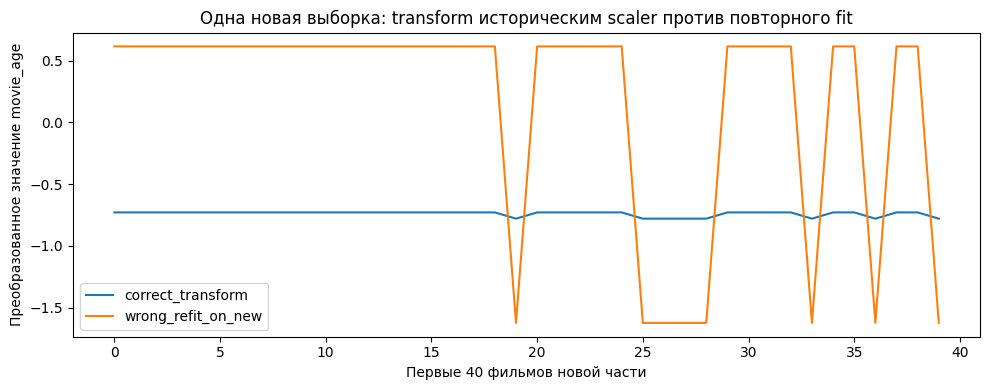

In [9]:
# -----------------------------------------------------------------------------
# Назначение ячейки: наглядно сравнить корректный transform и ошибочный повторный fit.
# В правильном варианте новая выборка масштабируется параметрами истории.
# В ошибочном варианте scaler заново обучается на новых данных, поэтому шкала меняется
# и значения перестают быть сопоставимыми с исторической матрицей.
# -----------------------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

history_age = historical[["movie_age"]].copy()
new_age = new_movies[["movie_age"]].copy()

correct_scaler = StandardScaler()
correct_scaler.fit(history_age)
new_age_correct = correct_scaler.transform(new_age).ravel()

wrong_scaler = StandardScaler()
new_age_wrong = wrong_scaler.fit_transform(new_age).ravel()

comparison = pd.DataFrame({
    "movie_age": new_age["movie_age"].to_numpy(),
    "correct_transform": new_age_correct,
    "wrong_refit_on_new": new_age_wrong,
})
display(comparison.head(10))

ax = comparison[["correct_transform", "wrong_refit_on_new"]].head(40).plot(
    figsize=(10, 4),
    title="Одна новая выборка: transform историческим scaler против повторного fit",
)
ax.set_xlabel("Первые 40 фильмов новой части")
ax.set_ylabel("Преобразованное значение movie_age")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correct_vs_wrong_scaling.png", dpi=140)
plt.show()

## 7. Визуальная проверка исторической и новой частей

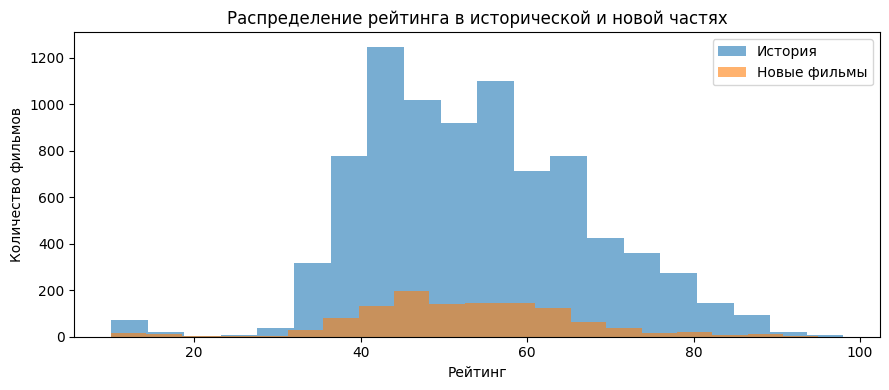

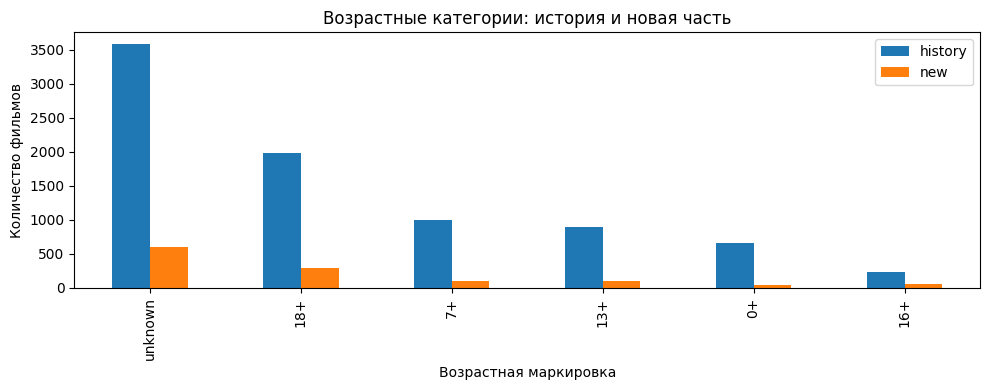

In [10]:
# -----------------------------------------------------------------------------
# Назначение ячейки: визуально сравнить историческую и новую части каталога.
# Наложенные гистограммы показывают возможный сдвиг распределения рейтинга,
# а столбчатая диаграмма — различия в возрастных категориях. Это диагностическая
# проверка данных, а не оценка качества модели.
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(historical["rating_score"].dropna(), bins=20, alpha=0.6, label="История")
ax.hist(new_movies["rating_score"].dropna(), bins=20, alpha=0.6, label="Новые фильмы")
ax.set_title("Распределение рейтинга в исторической и новой частях")
ax.set_xlabel("Рейтинг")
ax.set_ylabel("Количество фильмов")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "historical_vs_new_rating_distribution.png", dpi=140)
plt.show()

category_counts = pd.concat([
    historical["age_rating"].value_counts().rename("history"),
    new_movies["age_rating"].value_counts().rename("new"),
], axis=1).fillna(0)
ax = category_counts.plot(kind="bar", figsize=(10, 4), title="Возрастные категории: история и новая часть")
ax.set_xlabel("Возрастная маркировка")
ax.set_ylabel("Количество фильмов")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_rating_history_vs_new.png", dpi=140)
plt.show()

## 8. Неизвестная категория и `handle_unknown="ignore"`

Создаем одну демонстрационную строку с новой маркировкой `21+`. Pipeline не должен завершиться ошибкой.

In [11]:
# -----------------------------------------------------------------------------
# Назначение ячейки: проверить обработку ранее неизвестной категории.
# Значение '21+' искусственно создается только для демонстрации. Благодаря
# handle_unknown='ignore' pipeline не завершается ошибкой и сохраняет прежнее
# количество выходных признаков, что критично для применения к новым выгрузкам.
# -----------------------------------------------------------------------------

unknown_demo = X_new.head(1).copy()
unknown_demo["age_rating"] = "21+"
unknown_matrix = pipeline.transform(unknown_demo)

print("Преобразование новой категории выполнено. Размер:", unknown_matrix.shape)
assert unknown_matrix.shape[1] == history_matrix.shape[1]

Преобразование новой категории выполнено. Размер: (1, 12)


## 9. Сохранение pipeline и результатов

In [12]:
# -----------------------------------------------------------------------------
# Назначение ячейки: сохранить итоговые матрицы, имена признаков и сам pipeline.
# К преобразованным признакам добавляются идентификаторы и названия фильмов.
# joblib сохраняет обученный объект вместе с рассчитанными параметрами, чтобы позднее
# применять точно тот же preprocessing без повторного fit.
# -----------------------------------------------------------------------------

history_result = pd.concat([
    historical[["movie_id", "title", "release_year"]].reset_index(drop=True),
    history_preprocessed.reset_index(drop=True),
], axis=1)
new_result = pd.concat([
    new_movies[["movie_id", "title", "release_year"]].reset_index(drop=True),
    new_preprocessed.reset_index(drop=True),
], axis=1)

history_result.to_csv(
    PROCESSED_DIR / "historical_movies_preprocessed.csv", index=False, encoding="utf-8"
)
new_result.to_csv(
    PROCESSED_DIR / "new_movies_preprocessed.csv", index=False, encoding="utf-8"
)
pd.DataFrame({"feature_name": feature_names}).to_csv(
    OUTPUT_DIR / "preprocessing_feature_names.csv", index=False, encoding="utf-8"
)
joblib.dump(pipeline, OUTPUT_DIR / "preprocessing_pipeline.joblib")

print("Готово:", PROCESSED_DIR / "historical_movies_preprocessed.csv")
print("Готово:", PROCESSED_DIR / "new_movies_preprocessed.csv")
print("Pipeline:", OUTPUT_DIR / "preprocessing_pipeline.joblib")

Готово: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.2 Воспроизводимый preprocessing\data\processed\historical_movies_preprocessed.csv
Готово: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.2 Воспроизводимый preprocessing\data\processed\new_movies_preprocessed.csv
Pipeline: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.2 Воспроизводимый preprocessing\outputs\preprocessing_pipeline.joblib


## Итог пары и всего учебного дня

Слушатель должен уметь объяснить:

1. почему `fit` выполняется только на исторической части;
2. почему новая выгрузка проходит через `transform`;
3. как числовые и категориальные признаки обрабатываются разными цепочками;
4. почему `handle_unknown="ignore"` важен для производственного процесса;
5. как сохранить одинаковые правила преобразования для следующих выгрузок.